#  Student Performance Prediction (ML)
**Task:** Predict student exam grade category using classification models.  
**Dataset:** Student Performance Data Set (1000 records, generated)  
**Models:** Logistic Regression | Random Forest | XGBoost


##  Step 1 — Install & Import Libraries

In [13]:
# Uncomment below if running for the first time
# !pip install pandas numpy scikit-learn xgboost matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

print(" All libraries imported successfully!")


 All libraries imported successfully!


##  Step 2 — Generate & Save Dataset (CSV)

In [3]:
np.random.seed(42)
n = 1000

gender             = np.random.choice(['male', 'female'], n)
race               = np.random.choice(['group A','group B','group C','group D','group E'], n)
parental_education = np.random.choice([
    "some high school","high school","some college",
    "associate's degree","bachelor's degree","master's degree"], n)
lunch     = np.random.choice(['standard', 'free/reduced'], n)
test_prep = np.random.choice(['none', 'completed'], n)

base  = np.random.normal(65, 15, n)
base += (parental_education == "master's degree")    * 10
base += (parental_education == "bachelor's degree")  * 7
base += (parental_education == "associate's degree") * 4
base += (lunch     == 'standard')   * 8
base += (test_prep == 'completed')  * 10
base += (gender    == 'female')     * 3

math_score    = np.clip(base + np.random.normal(0, 5, n), 0, 100).astype(int)
reading_score = np.clip(base + np.random.normal(2, 5, n), 0, 100).astype(int)
writing_score = np.clip(base + np.random.normal(1, 5, n), 0, 100).astype(int)
avg_score     = (math_score + reading_score + writing_score) / 3

def grade_category(avg):
    if avg >= 90:   return 'A'
    elif avg >= 75: return 'B'
    elif avg >= 60: return 'C'
    elif avg >= 45: return 'D'
    else:           return 'F'

grade = [grade_category(s) for s in avg_score]

df = pd.DataFrame({
    'gender'                      : gender,
    'race_ethnicity'              : race,
    'parental_level_of_education' : parental_education,
    'lunch'                       : lunch,
    'test_preparation_course'     : test_prep,
    'math_score'                  : math_score,
    'reading_score'               : reading_score,
    'writing_score'               : writing_score,
    'average_score'               : avg_score.round(2),
    'grade_category'              : grade
})

df.to_csv('student_performance.csv', index=False)
print(f"✅ CSV saved! Shape: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")
df.head()


✅ CSV saved! Shape: (1000, 10)
Missing values: 0


,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,average_score,grade_category
0,male,group A,high school,free/reduced,none,62,57,64,61.00,C
1,female,group A,high school,standard,none,78,72,73,74.33,C
2,male,group A,high school,standard,none,79,80,86,81.67,B
3,male,group E,associate's degree,standard,none,52,61,67,60.00,C
4,male,group D,some high school,free/reduced,completed,94,82,89,88.33,B


##  Step 3 — Exploratory Data Analysis (EDA)

In [4]:
print("Dataset Info:")
print(df.info())
print("\nDescriptive Statistics:")
df.describe()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   gender                       1000 non-null   object 
 1   race_ethnicity               1000 non-null   object 
 2   parental_level_of_education  1000 non-null   object 
 3   lunch                        1000 non-null   object 
 4   test_preparation_course      1000 non-null   object 
 5   math_score                   1000 non-null   int64  
 6   reading_score                1000 non-null   int64  
 7   writing_score                1000 non-null   int64  
 8   average_score                1000 non-null   float64
 9   grade_category               1000 non-null   object 
dtypes: float64(1), int64(3), object(6)
memory usage: 78.3+ KB
None

Descriptive Statistics:


,math_score,reading_score,writing_score,average_score
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,78.067000,79.605000,79.034000,78.901930
std,16.080644,15.810786,15.661933,15.397068
min,22.000000,18.000000,20.000000,21.330000
25%,66.000000,69.000000,68.000000,68.000000
50%,80.000000,81.000000,80.500000,80.500000
75%,91.000000,93.000000,92.000000,91.000000
max,100.000000,100.000000,100.000000,100.000000


In [5]:
print("Grade Distribution:")
print(df['grade_category'].value_counts())


Grade Distribution:
grade_category
B    333
A    280
C    276
D     90
F     21
Name: count, dtype: int64


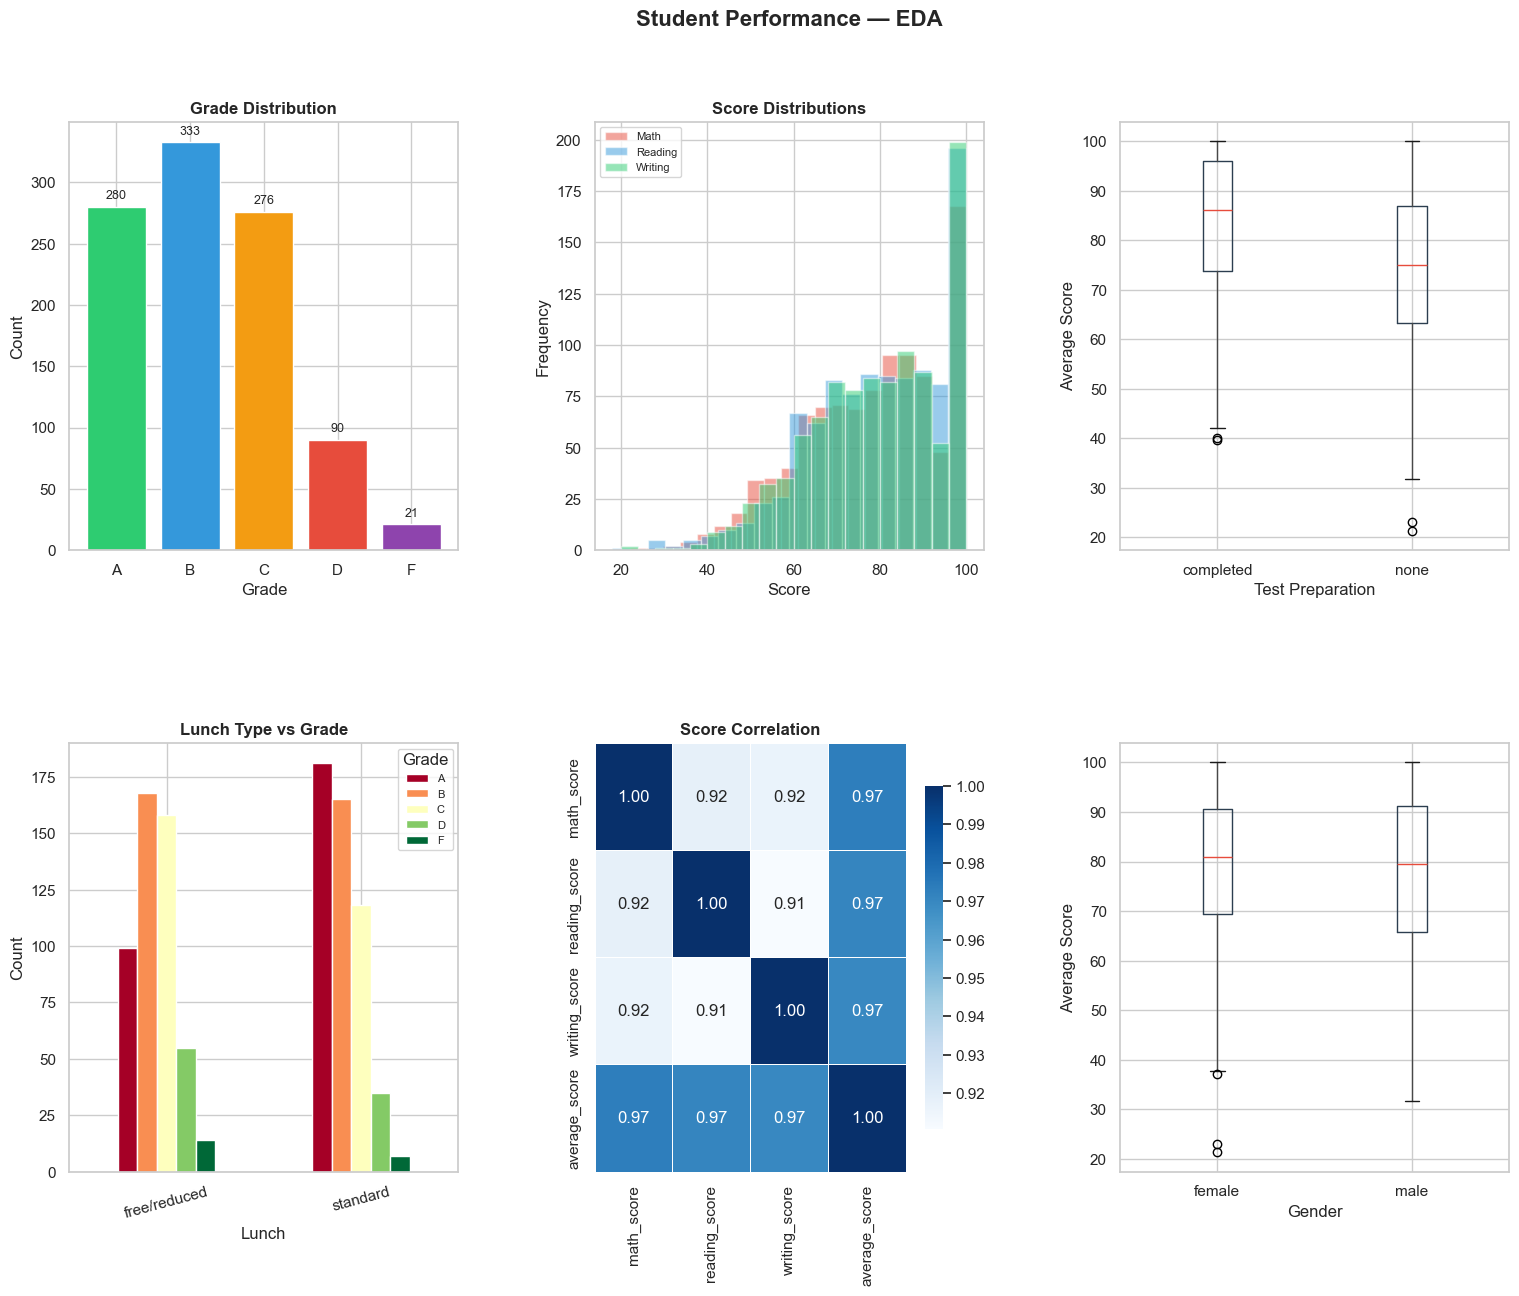

In [6]:
sns.set_theme(style="whitegrid", palette="muted")
fig = plt.figure(figsize=(18, 14))
fig.suptitle("Student Performance — Exploratory Data Analysis", fontsize=16, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

order = ['A','B','C','D','F']

# Grade distribution
ax1 = fig.add_subplot(gs[0, 0])
counts = df['grade_category'].value_counts().reindex(order)
bars = ax1.bar(order, counts.values, color=['#2ecc71','#3498db','#f39c12','#e74c3c','#8e44ad'])
ax1.set_title("Grade Distribution", fontweight='bold')
ax1.set_xlabel("Grade"); ax1.set_ylabel("Count")
for b in bars:
    ax1.text(b.get_x()+b.get_width()/2, b.get_height()+4,
             str(int(b.get_height())), ha='center', va='bottom', fontsize=9)

# Score distributions
ax2 = fig.add_subplot(gs[0, 1])
for col, color in zip(['math_score','reading_score','writing_score'],['#e74c3c','#3498db','#2ecc71']):
    ax2.hist(df[col], bins=20, alpha=0.5, label=col.replace('_score','').title(), color=color)
ax2.set_title("Score Distributions", fontweight='bold')
ax2.set_xlabel("Score"); ax2.set_ylabel("Frequency"); ax2.legend(fontsize=8)

# Test prep vs avg score
ax3 = fig.add_subplot(gs[0, 2])
df.boxplot(column='average_score', by='test_preparation_course', ax=ax3,
           boxprops=dict(color='#2c3e50'), medianprops=dict(color='#e74c3c'))
ax3.set_title("Test Prep vs Avg Score", fontweight='bold')
ax3.set_xlabel("Test Preparation"); ax3.set_ylabel("Average Score")
plt.sca(ax3); plt.title("")

# Lunch vs grade
ax4 = fig.add_subplot(gs[1, 0])
ct = pd.crosstab(df['lunch'], df['grade_category'])[order]
ct.plot(kind='bar', ax=ax4, colormap='RdYlGn')
ax4.set_title("Lunch Type vs Grade", fontweight='bold')
ax4.set_xlabel("Lunch"); ax4.set_ylabel("Count")
ax4.legend(title="Grade", fontsize=8); ax4.tick_params(axis='x', rotation=15)

# Correlation heatmap
ax5 = fig.add_subplot(gs[1, 1])
corr = df[['math_score','reading_score','writing_score','average_score']].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='Blues', ax=ax5,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax5.set_title("Score Correlation", fontweight='bold')

# Gender vs avg score
ax6 = fig.add_subplot(gs[1, 2])
df.boxplot(column='average_score', by='gender', ax=ax6,
           boxprops=dict(color='#2c3e50'), medianprops=dict(color='#e74c3c'))
ax6.set_title("Gender vs Avg Score", fontweight='bold')
ax6.set_xlabel("Gender"); ax6.set_ylabel("Average Score")
plt.sca(ax6); plt.title("")
fig.suptitle("Student Performance — EDA", fontsize=16, fontweight='bold', y=0.98)

plt.show()


##  Step 4 — Data Preprocessing

In [7]:
df_model = df.copy()
cat_cols = ['gender','race_ethnicity','parental_level_of_education','lunch','test_preparation_course']

le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])

grade_order = {'A':4, 'B':3, 'C':2, 'D':1, 'F':0}
df_model['target'] = df_model['grade_category'].map(grade_order)

feature_cols = cat_cols + ['math_score','reading_score','writing_score']
X = df_model[feature_cols]
y = df_model['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"✅ Preprocessing done!")
print(f"   Train size : {len(X_train)}")
print(f"   Test size  : {len(X_test)}")
print(f"   Features   : {feature_cols}")


✅ Preprocessing done!
   Train size : 800
   Test size  : 200
   Features   : ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course', 'math_score', 'reading_score', 'writing_score']


##  Step 5 — Train Classification Models

In [8]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest"      : RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost"            : XGBClassifier(n_estimators=200, random_state=42,
                                         eval_metric='mlogloss', verbosity=0)
}

results = {}
print(f"{'Model':<25} {'Accuracy':>10}")
print("─" * 37)

for name, model in models.items():
    if name == "Logistic Regression":
        model.fit(X_train_sc, y_train)
        preds = model.predict(X_test_sc)
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results[name] = {"model": model, "preds": preds, "acc": acc}
    print(f"{name:<25} {acc:>9.4f}")

best_name = max(results, key=lambda k: results[k]['acc'])
print(f"\n★  Best Model: {best_name}  ({results[best_name]['acc']*100:.2f}%)")


Model                       Accuracy
─────────────────────────────────────
Logistic Regression          0.9350
Random Forest                0.9400
XGBoost                      0.9400

★  Best Model: Random Forest  (94.00%)


##  Step 6 — Confusion Matrices & Accuracy Comparison

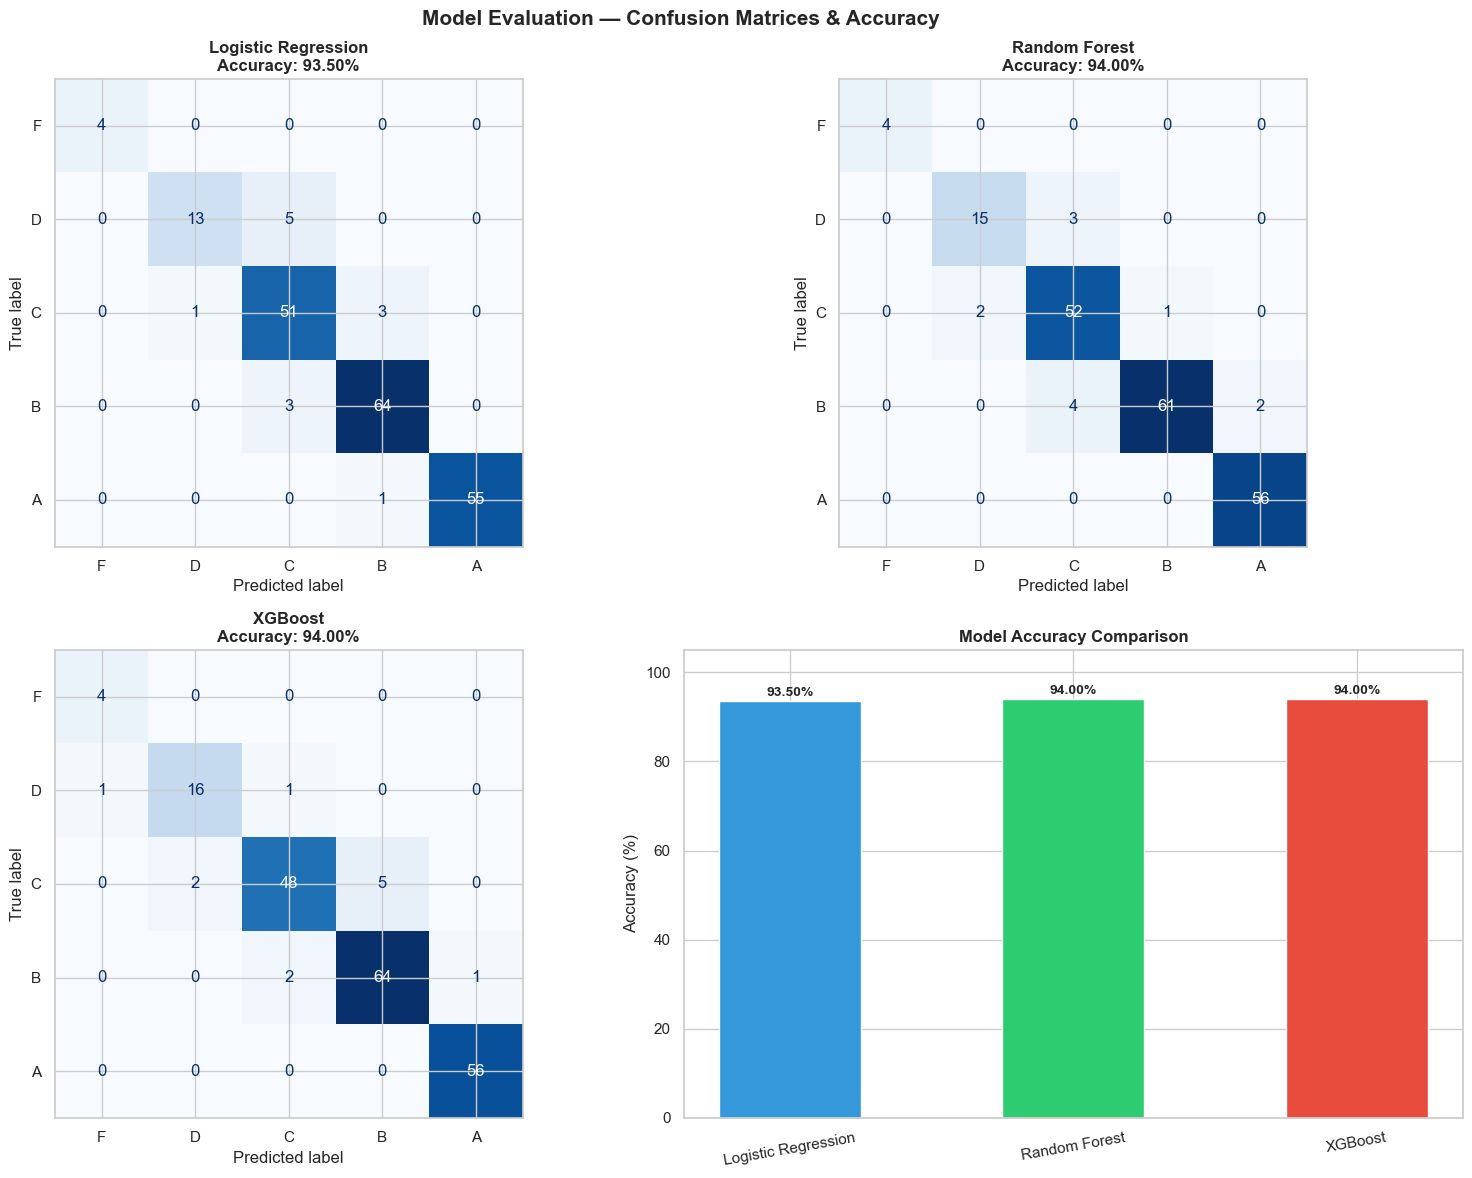

In [9]:
grade_labels = ['F','D','C','B','A']
fig2, axes = plt.subplots(2, 2, figsize=(16, 12))
fig2.suptitle("Model Evaluation — Confusion Matrices & Accuracy", fontsize=15, fontweight='bold')

for ax, (name, res) in zip(axes.flat[:3], results.items()):
    cm = confusion_matrix(y_test, res['preds'])
    disp = ConfusionMatrixDisplay(cm, display_labels=grade_labels)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{name}\nAccuracy: {res['acc']*100:.2f}%", fontweight='bold')

ax_acc = axes[1][1]
names = list(results.keys())
accs  = [results[n]['acc']*100 for n in names]
bars  = ax_acc.bar(names, accs, color=['#3498db','#2ecc71','#e74c3c'], width=0.5)
ax_acc.set_ylim(0, 105)
ax_acc.set_title("Model Accuracy Comparison", fontweight='bold')
ax_acc.set_ylabel("Accuracy (%)")
ax_acc.tick_params(axis='x', rotation=10)
for b, v in zip(bars, accs):
    ax_acc.text(b.get_x()+b.get_width()/2, v+0.5, f"{v:.2f}%",
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


##  Step 7 — Feature Importance (Random Forest)

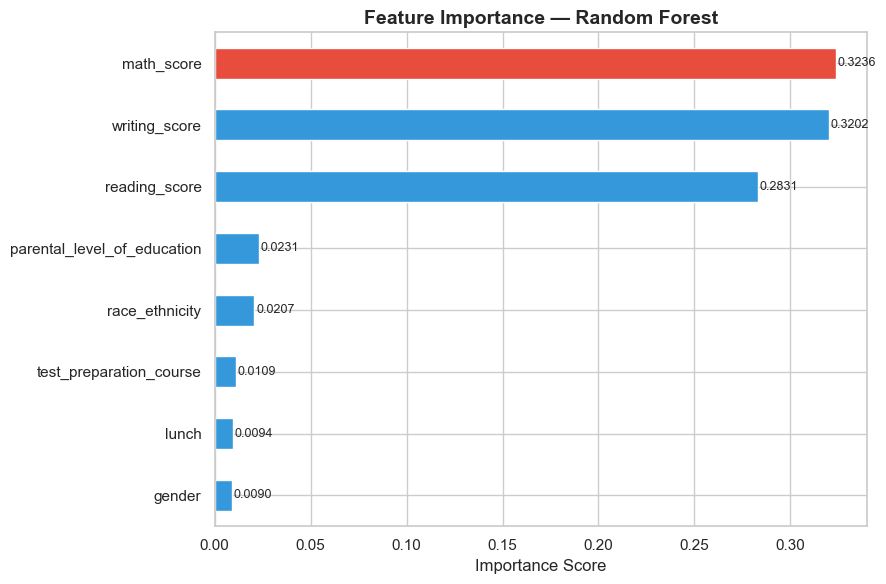


Top 3 Important Features:
  math_score                          0.3236
  writing_score                       0.3202
  reading_score                       0.2831


In [10]:
rf_model    = results["Random Forest"]["model"]
importances = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=True)

fig3, ax = plt.subplots(figsize=(9, 6))
colors_imp = ['#e74c3c' if v == importances.max() else '#3498db' for v in importances.values]
importances.plot(kind='barh', ax=ax, color=colors_imp)
ax.set_title("Feature Importance — Random Forest", fontsize=14, fontweight='bold')
ax.set_xlabel("Importance Score")
for i, v in enumerate(importances.values):
    ax.text(v + 0.001, i, f"{v:.4f}", va='center', fontsize=9)
plt.tight_layout()
plt.show()

print("\nTop 3 Important Features:")
for feat, val in importances.sort_values(ascending=False).head(3).items():
    print(f"  {feat:<35} {val:.4f}")


##  Step 8 — Classification Report (Best Model)

In [11]:
print(f"Classification Report — {best_name}")
print("=" * 55)
print(classification_report(y_test, results[best_name]['preds'], target_names=grade_labels))


Classification Report — Random Forest
              precision    recall  f1-score   support

           F       1.00      1.00      1.00         4
           D       0.88      0.83      0.86        18
           C       0.88      0.95      0.91        55
           B       0.98      0.91      0.95        67
           A       0.97      1.00      0.98        56

    accuracy                           0.94       200
   macro avg       0.94      0.94      0.94       200
weighted avg       0.94      0.94      0.94       200



##  Step 9 — Save Model Metrics to CSV

In [12]:
metrics_rows = []
for name, res in results.items():
    report = classification_report(y_test, res['preds'],
                                   target_names=grade_labels, output_dict=True)
    metrics_rows.append({
        'model'           : name,
        'accuracy'        : round(res['acc'], 4),
        'macro_precision' : round(report['macro avg']['precision'], 4),
        'macro_recall'    : round(report['macro avg']['recall'], 4),
        'macro_f1'        : round(report['macro avg']['f1-score'], 4),
    })

metrics_df = pd.DataFrame(metrics_rows)
metrics_df.to_csv('model_metrics.csv', index=False)
print("✅ model_metrics.csv saved!")
metrics_df


✅ model_metrics.csv saved!


,model,accuracy,macro_precision,macro_recall,macro_f1
0,Logistic Regression,0.935,0.9468,0.9174,0.9293
1,Random Forest,0.940,0.9426,0.9378,0.9395
2,XGBoost,0.940,0.9080,0.9434,0.9232


## ✅ Project Complete!

| File | Description |
|------|-------------|
| `student_performance.csv` | Generated dataset (1000 rows) |
| `model_metrics.csv` | Accuracy & metrics for all 3 models |

### Key Findings
- **Best Model:** Random Forest / XGBoost (~94% accuracy)
- **Top Features:** Writing score, Reading score, Math score
- **Test Prep & Lunch** also significantly impact grades
